# [Analytical] Analysis of KV Cache Compression Policies

**Project:** Systematic evaluation of KV cache compression methods (R-KV and ChunkKV) on long-context tasks using Qwen2.5-1.5B-Instruct and LongBench.

**Objectives:**
1. Survey and implement R-KV and ChunkKV compression techniques
2. Set up a unified testbed with controllable cache budget (e.g., 10%, 20%, 50%)
3. Evaluate on 6 LongBench tasks (50 examples each) and measure accuracy + speedup vs. full context
4. Provide theoretical and empirical analysis of efficiency-accuracy trade-offs

## 1. Survey: R-KV and ChunkKV

### R-KV (Redundancy-aware KV Cache Compression)
- **Source:** R-KV: Redundancy-aware KV Cache Compression for Reasoning Models (NeurIPS 2025).
- **Idea:** Training-free compression that ranks tokens by **importance** and **non-redundancy**. Removes repetitive tokens while keeping informative ones.
- **Mechanism:** Joint selection using redundancy estimation (e.g., similarity to recent context), importance scoring (e.g., attention-based), and combined scoring.
- **Results:** ~100% accuracy with 10% cache; 105% at 16% cache; 90% memory savings and ~6.6× throughput on long CoT.

### ChunkKV (Semantic-Preserving KV Cache Compression)
- **Source:** ChunkKV (NeurIPS 2025); implementation in NVIDIA KVPress.
- **Idea:** Use **semantic chunks** (not single tokens) as the compression unit to preserve linguistic structure and context.
- **Mechanism:** Chunk-level importance, layer-wise index reuse for efficiency.
- **Results:** Up to 8.7% better precision at same compression ratio; ~26.5% throughput improvement on LongBench and related benchmarks.

In [ ]:
# Install dependencies (run once)
!pip install -q transformers datasets torch accelerate kvpress rouge

In [1]:
import os
import re
import string
import time
import json
import math
import gc
import numpy as np
import pandas as pd
import torch
from torch.nn import functional as F
from pathlib import Path
from collections import defaultdict, Counter
from typing import Any, List, Dict, Optional, Tuple
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.cache_utils import DynamicCache
from datasets import load_dataset
from rouge import Rouge as _RougeLib

In [2]:
MAX_INPUT_TOKENS = 4096
MAX_NEW_TOKENS = 64

## 2. Unified Testbed

We load **Qwen2.5-1.5B-Instruct** with `attn_implementation="eager"` (required to read actual attention weights per step) and `bfloat16` precision. The testbed implements **true KV cache eviction** during generation — not input truncation:

- **Full baseline:** Step-by-step greedy generation with no eviction; cache grows to full length.
- **R-KV eviction:** At each decode step, token KV entries are scored jointly by (1) **cumulative attention importance** accumulated across decode steps and (2) **key cosine non-redundancy** (how dissimilar a token's key is from its local window). Entries with the lowest joint score are evicted to maintain the target budget. A `recent_window` of tokens is always pinned to prevent evicting immediately useful context.
- **ChunkKV eviction:** KV entries are grouped into fixed-size chunks (64 tokens). Chunks are scored by their **mean cumulative attention weight** and low-scoring chunks are evicted. The same chunk selection is shared across all layers (layer index reuse), which reduces per-layer overhead.

Prompts are built with `tokenizer.apply_chat_template()` and a smart **head + tail** truncation strategy: for contexts exceeding `MAX_INPUT_TOKENS`, the first half and last half of the context are preserved to maintain both background and conclusion.

Evaluation uses **token-level F1** for QA tasks and **ROUGE-L** for summarization (`gov_report`), and records: task score, latency, tokens/sec, generated tokens, final cache length, and average cache length per decode step.

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
print(f"Loading model: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    attn_implementation="eager",   # required for output_attentions=True during decode steps
    low_cpu_mem_usage=True,
)

if DEVICE == "cpu":
    model = model.to(DEVICE)

model.eval()

n_layers = model.config.num_hidden_layers
n_params = sum(p.numel() for p in model.parameters()) / 1e9

print(f"Model  : {MODEL_ID}")
print(f"Params : {n_params:.2f}B")
print(f"Layers : {n_layers}")

Loading model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model  : Qwen/Qwen2.5-1.5B-Instruct
Params : 1.54B
Layers : 28


Model  : Qwen/Qwen2.5-1.5B-Instruct
Params : 1.54B
Layers : 28


Model  : Qwen/Qwen2.5-1.5B-Instruct
Params : 1.54B
Layers : 28


In [5]:
# ──────────────────────────────────────────────
# DynamicCache utility helpers
# ──────────────────────────────────────────────

class _OurCache(DynamicCache):
    """
    DynamicCache subclass with guaranteed key_cache / value_cache plain list storage.

    In transformers >= 4.47, DynamicCache's internal storage was redesigned so that
    calling .update() no longer writes into key_cache / value_cache list attributes.
    Qwen2 models also automatically create a HybridCache (for mixed sliding-window
    + full attention) which inherits from DynamicCache but uses different internals.

    By overriding update() here we ensure that every call the model makes to
    cache.update(k, v, layer_idx) — including from inside each attention layer —
    writes into self.key_cache / self.value_cache lists that our compression code
    can access reliably.  object.__setattr__ / object.__getattribute__ are used to
    bypass any property descriptors the parent class might define on these names.
    """

    def __init__(self):
        try:
            super().__init__()
        except Exception:
            pass
        object.__setattr__(self, "key_cache", [])
        object.__setattr__(self, "value_cache", [])
        if not hasattr(self, "_seen_tokens"):
            object.__setattr__(self, "_seen_tokens", 0)

    def update(self, key_states, value_states, layer_idx, cache_kwargs=None):
        kc = object.__getattribute__(self, "key_cache")
        vc = object.__getattribute__(self, "value_cache")
        while len(kc) <= layer_idx:
            kc.append(None)
            vc.append(None)
        if kc[layer_idx] is None:
            kc[layer_idx] = key_states
            vc[layer_idx] = value_states
        else:
            kc[layer_idx] = torch.cat([kc[layer_idx], key_states], dim=-2)
            vc[layer_idx] = torch.cat([vc[layer_idx], value_states], dim=-2)
        try:
            object.__setattr__(self, "_seen_tokens", kc[0].shape[-2])
        except Exception:
            pass
        return kc[layer_idx], vc[layer_idx]

    def get_seq_length(self, layer_idx=0):
        kc = object.__getattribute__(self, "key_cache")
        if kc and kc[0] is not None:
            return kc[0].shape[-2]
        return 0

    def get_max_cache_shape(self):
        return None

    def to_legacy_cache(self):
        kc = object.__getattribute__(self, "key_cache")
        vc = object.__getattribute__(self, "value_cache")
        return tuple((k, v) for k, v in zip(kc, vc) if k is not None)

    def __len__(self):
        return len(object.__getattribute__(self, "key_cache"))


def _extract_kv_pairs(cache_obj):
    """Extract (key, value) pairs for all layers from any cache type."""
    # Our own cache — direct access bypassing descriptors
    if isinstance(cache_obj, _OurCache):
        kc = object.__getattribute__(cache_obj, "key_cache")
        vc = object.__getattribute__(cache_obj, "value_cache")
        return [(k, v) for k, v in zip(kc, vc) if k is not None]

    # Standard DynamicCache with key_cache as a plain list
    if (hasattr(cache_obj, "key_cache")
            and isinstance(cache_obj.key_cache, list)
            and len(cache_obj.key_cache) > 0):
        return [(k, v) for k, v in zip(cache_obj.key_cache, cache_obj.value_cache)
                if k is not None]

    # to_legacy_cache() — available on most Cache types
    if hasattr(cache_obj, "to_legacy_cache"):
        try:
            legacy = cache_obj.to_legacy_cache()
            if legacy:
                return [(t[0], t[1]) for t in legacy]
        except Exception:
            pass

    # Raw tuple / list format (very old transformers)
    if isinstance(cache_obj, (list, tuple)):
        pairs = [(kv[0], kv[1]) for kv in cache_obj
                 if isinstance(kv, (list, tuple)) and len(kv) >= 2]
        if pairs:
            return pairs

    return []


def ensure_dynamic_cache(past_key_values):
    """
    Always return an _OurCache with guaranteed key_cache / value_cache lists.

    Fast path (zero copy): if already an _OurCache, return it directly.
    Slow path (one-time): extract tensors from the model's native cache type
    (HybridCache, legacy DynamicCache, etc.) and copy into a fresh _OurCache.
    After this first conversion all subsequent decode steps hit the fast path
    because the model mutates our _OurCache in-place via update().
    """
    if past_key_values is None:
        return _OurCache()
    if isinstance(past_key_values, _OurCache):
        return past_key_values
    kv_pairs = _extract_kv_pairs(past_key_values)
    cache = _OurCache()
    for i, (k, v) in enumerate(kv_pairs):
        cache.update(k, v, i)
    return cache


def cache_seq_len(cache_obj) -> int:
    kc = object.__getattribute__(cache_obj, "key_cache") if isinstance(cache_obj, _OurCache) else getattr(cache_obj, "key_cache", None)
    if isinstance(kc, list) and kc and kc[0] is not None:
        return kc[0].shape[-2]
    try:
        return cache_obj.get_seq_length()
    except Exception:
        return 0


def num_cache_layers(cache_obj) -> int:
    kc = object.__getattribute__(cache_obj, "key_cache") if isinstance(cache_obj, _OurCache) else getattr(cache_obj, "key_cache", None)
    if isinstance(kc, list):
        return len(kc)
    return len(_extract_kv_pairs(cache_obj))


def get_cache_tensors(cache_obj, layer_idx: int):
    """Return (keys, values) tensors for a given layer. Shape: (batch, heads, seq, head_dim)."""
    if isinstance(cache_obj, _OurCache):
        kc = object.__getattribute__(cache_obj, "key_cache")
        vc = object.__getattribute__(cache_obj, "value_cache")
        return kc[layer_idx], vc[layer_idx]
    return cache_obj.key_cache[layer_idx], cache_obj.value_cache[layer_idx]


def slice_dynamic_cache(cache_obj, keep_idx_per_layer: List[torch.Tensor]):
    """Return a new _OurCache containing only the selected KV positions per layer."""
    new_cache = _OurCache()
    for layer_idx in range(num_cache_layers(cache_obj)):
        k, v = get_cache_tensors(cache_obj, layer_idx)
        idx = keep_idx_per_layer[layer_idx].to(k.device)
        new_cache.update(k.index_select(-2, idx), v.index_select(-2, idx), layer_idx)
    return new_cache


print("Cache utilities loaded.")

Cache utilities loaded.


In [15]:
# ──────────────────────────────────────────────
# Prompt builder: chat template + head/tail truncation
# ──────────────────────────────────────────────

def get_field(example: dict, names: List[str], default=""):
    for n in names:
        if n in example and example[n] is not None:
            return example[n]
    return default


def build_prompt(example: dict, task_name: str, max_input_tokens: int = MAX_INPUT_TOKENS) -> str:
    context = get_field(example, ["context", "article", "passage"], "")
    question = get_field(example, ["input", "question", "query", "instruction"], "")

    if task_name == "gov_report":
        user_content = (
            "Read the following document and write a concise summary.\n\n"
            f"Document:\n{context}\n\nSummary:"
        )
    else:
        user_content = (
            "Read the context below and answer the question concisely. "
            "Give the best supported answer only.\n\n"
            f"Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"
        )

    messages = [{"role": "user", "content": user_content}]
    full_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    ids = tokenizer(full_text, return_tensors="pt", add_special_tokens=False)["input_ids"][0]

    if len(ids) <= max_input_tokens:
        return full_text

    # Smart head + tail truncation when prompt exceeds budget
    if task_name == "gov_report":
        prefix = "Read the following document and write a concise summary.\n\nDocument:\n"
        suffix = "\n\nSummary:"
    else:
        prefix = (
            "Read the context below and answer the question concisely. "
            "Give the best supported answer only.\n\nContext:\n"
        )
        suffix = f"\n\nQuestion:\n{question}\n\nAnswer:"

    prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
    suffix_ids = tokenizer(suffix, add_special_tokens=False)["input_ids"]

    # Reserve space for chat template overhead (~50 tokens)
    available = max_input_tokens - len(prefix_ids) - len(suffix_ids) - 50
    available = max(256, available)

    ctx_ids = tokenizer(context, add_special_tokens=False)["input_ids"]
    if len(ctx_ids) > available:
        head = ctx_ids[: available // 2]
        tail = ctx_ids[-(available - len(head)):]
        ctx_ids = head + tail

    truncated_context = tokenizer.decode(ctx_ids, skip_special_tokens=True)

    if task_name == "gov_report":
        user_content = f"Read the following document and write a concise summary.\n\nDocument:\n{truncated_context}\n\nSummary:"
    else:
        user_content = (
            "Read the context below and answer the question concisely. "
            f"Give the best supported answer only.\n\nContext:\n{truncated_context}\n\nQuestion:\n{question}\n\nAnswer:"
        )

    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


print("Prompt builder loaded.")


# ──────────────────────────────────────────────
# Full-context baseline: step-by-step generation
# ──────────────────────────────────────────────

@torch.no_grad()
def generate_baseline_stepwise(prompt: str, max_new_tokens: int = MAX_NEW_TOKENS) -> dict:
    """Greedy step-by-step generation with full KV cache (no eviction). Tracks cache growth."""
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=MAX_INPUT_TOKENS,
    ).to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    # Prefill — pass _OurCache() so the model writes into our key_cache/value_cache
    # lists directly, avoiding any post-hoc conversion from HybridCache / new DynamicCache.
    out = model(**inputs, use_cache=True, past_key_values=_OurCache(),
                output_attentions=False, return_dict=True)
    past = ensure_dynamic_cache(out.past_key_values)
    next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    generated = [next_token.item()]
    cache_lens = [cache_seq_len(past)]

    # Decode
    for _ in range(max_new_tokens - 1):
        out = model(
            input_ids=next_token,
            past_key_values=past,
            use_cache=True,
            output_attentions=False,
            return_dict=True,
        )
        past = ensure_dynamic_cache(out.past_key_values)
        next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        tok = next_token.item()
        generated.append(tok)
        cache_lens.append(cache_seq_len(past))
        if tok == tokenizer.eos_token_id:
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    latency = t1 - t0
    record = {
        "text": tokenizer.decode(generated, skip_special_tokens=True).strip(),
        "latency": latency,
        "tokens_per_sec": len(generated) / max(latency, 1e-6),
        "generated_tokens": len(generated),
        "final_cache_len": cache_seq_len(past),
        "avg_cache_len": float(np.mean(cache_lens)),
    }
    # Free KV cache tensors immediately so they don't accumulate across examples
    del out, past, inputs, cache_lens, generated
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return record


print("Baseline generator loaded.")

Prompt builder loaded.
Baseline generator loaded.


In [16]:
# ──────────────────────────────────────────────
# R-KV Compressor (attention importance × key non-redundancy)
# ──────────────────────────────────────────────

class RKVCompressor:
    """
    R-KV style KV cache eviction.

    Scoring:  joint_score = cumulative_attention_importance × key_non_redundancy
    - importance: accumulated mean attention weight directed at each KV position
      across all decode steps (more often attended = more important).
    - non_redundancy: 1 - max cosine similarity between a token's key vector and
      its recent-window neighbours (tokens with unique keys are kept preferentially).

    A `recent_window` of the most recent tokens is always pinned regardless of score.
    """

    def __init__(self, budget_ratio: float = 0.5, recent_window: int = 128, chunk_size: int = 64):
        self.budget_ratio = budget_ratio
        self.recent_window = recent_window
        self.importance: Optional[List[torch.Tensor]] = None

    def _init_importance(self, cache_obj: DynamicCache):
        seq_len = cache_seq_len(cache_obj)
        k0, _ = get_cache_tensors(cache_obj, 0)
        self.importance = [
            torch.zeros(seq_len, device=k0.device, dtype=torch.float32)
            for _ in range(num_cache_layers(cache_obj))
        ]

    def update_importance(self, attentions: tuple, cache_obj: DynamicCache):
        """Accumulate per-position attention weights from the current decode step."""
        if self.importance is None:
            self._init_importance(cache_obj)

        for layer_idx, attn in enumerate(attentions):
            # attn: (batch, heads, q_len, kv_len) — q_len=1 during decode
            score = attn.mean(dim=1)[0, -1, :].float()  # (kv_len,)
            cur = self.importance[layer_idx]
            if score.shape[0] > cur.shape[0]:
                pad = torch.zeros(score.shape[0] - cur.shape[0], device=cur.device)
                cur = torch.cat([cur, pad], dim=0)
            cur[: score.shape[0]] += score
            self.importance[layer_idx] = cur

    def _non_redundancy(self, keys: torch.Tensor, old_end: int) -> torch.Tensor:
        """
        For each token in [0, old_end) compute 1 - max cosine similarity with its
        preceding recent_window neighbours.  Fully vectorized: one masked matmul
        on GPU instead of a Python loop (critical for long contexts).
        """
        if old_end <= 1:
            return torch.ones(old_end, device=keys.device)

        # (1, heads, seq, head_dim) → mean over heads → (old_end, head_dim)
        k = keys[0].mean(dim=0)[:old_end].float()
        k_norm = F.normalize(k, dim=-1)          # (old_end, head_dim)

        # Full pairwise cosine similarity matrix: (old_end, old_end)
        sim = k_norm @ k_norm.T

        # Causal windowed mask: position i looks at columns in [i-W, i)
        W = self.recent_window
        idx = torch.arange(old_end, device=k.device)
        valid = (idx.unsqueeze(0) < idx.unsqueeze(1)) & \
                (idx.unsqueeze(0) >= idx.unsqueeze(1) - W)   # (old_end, old_end)

        sim.masked_fill_(~valid, -1.0)           # -1 < any real cosine sim in [0,1]
        max_sim = sim.max(dim=1).values.clamp(0.0, 1.0)
        max_sim[0] = 0.0                         # position 0 has no predecessors
        return 1.0 - max_sim

    def compress(self, cache_obj: DynamicCache) -> DynamicCache:
        seq_len = cache_seq_len(cache_obj)
        # Use fixed budget anchored to prefill length (set by generate_with_compressor)
        # to avoid repeated re-compression of an already-small cache.
        keep_total = getattr(self, "_kv_budget", max(self.recent_window, int(seq_len * self.budget_ratio)))
        if keep_total >= seq_len or self.budget_ratio >= 1.0:
            return cache_obj

        recent_start = max(0, seq_len - self.recent_window)
        old_end = recent_start
        recent_idx = torch.arange(recent_start, seq_len)

        keep_idx_per_layer: List[torch.Tensor] = []

        for layer_idx in range(num_cache_layers(cache_obj)):
            imp = self.importance[layer_idx][:seq_len]
            old_budget = keep_total - len(recent_idx)

            if old_budget <= 0 or old_end == 0:
                keep_idx = recent_idx
            else:
                keys, _ = get_cache_tensors(cache_obj, layer_idx)
                nr = self._non_redundancy(keys, old_end)
                joint = imp[:old_end] * (0.5 + 0.5 * nr)
                topk = min(old_budget, old_end)
                old_idx = torch.topk(joint, k=topk).indices.sort().values.cpu()
                keep_idx = torch.cat([old_idx, recent_idx.cpu()], dim=0)

            keep_idx_per_layer.append(keep_idx)

        new_cache = slice_dynamic_cache(cache_obj, keep_idx_per_layer)

        # Update accumulated importance to match the sliced cache
        self.importance = [
            self.importance[i].index_select(0, keep_idx_per_layer[i].to(self.importance[i].device))
            for i in range(len(self.importance))
        ]
        return new_cache


# ──────────────────────────────────────────────
# ChunkKV Compressor (chunk-level, layer index reuse)
# ──────────────────────────────────────────────

class ChunkKVCompressor:
    """
    ChunkKV style KV cache eviction.

    Tokens are grouped into fixed-size chunks; each chunk's score is the mean
    cumulative attention importance of its members.  Low-scoring chunks are evicted.
    The same chunk selection is used for **all layers** (layer index reuse), reducing
    per-layer computation overhead.  A `recent_window` is always pinned.
    """

    def __init__(self, budget_ratio: float = 0.5, recent_window: int = 128, chunk_size: int = 64):
        self.budget_ratio = budget_ratio
        self.recent_window = recent_window
        self.chunk_size = chunk_size
        self.importance: Optional[List[torch.Tensor]] = None

    def _init_importance(self, cache_obj: DynamicCache):
        seq_len = cache_seq_len(cache_obj)
        k0, _ = get_cache_tensors(cache_obj, 0)
        self.importance = [
            torch.zeros(seq_len, device=k0.device, dtype=torch.float32)
            for _ in range(num_cache_layers(cache_obj))
        ]

    def update_importance(self, attentions: tuple, cache_obj: DynamicCache):
        if self.importance is None:
            self._init_importance(cache_obj)

        for layer_idx, attn in enumerate(attentions):
            score = attn.mean(dim=1)[0, -1, :].float()
            cur = self.importance[layer_idx]
            if score.shape[0] > cur.shape[0]:
                pad = torch.zeros(score.shape[0] - cur.shape[0], device=cur.device)
                cur = torch.cat([cur, pad], dim=0)
            cur[: score.shape[0]] += score
            self.importance[layer_idx] = cur

    def compress(self, cache_obj: DynamicCache) -> DynamicCache:
        seq_len = cache_seq_len(cache_obj)
        # Use fixed budget anchored to prefill length (set by generate_with_compressor)
        keep_total = getattr(self, "_kv_budget", max(self.recent_window, int(seq_len * self.budget_ratio)))
        if keep_total >= seq_len or self.budget_ratio >= 1.0:
            return cache_obj

        recent_start = max(0, seq_len - self.recent_window)
        old_end = recent_start
        old_budget = max(0, keep_total - self.recent_window)

        # Average importance across layers for shared chunk scoring (layer index reuse)
        n_layers = num_cache_layers(cache_obj)
        avg_imp = torch.stack([self.importance[i][:seq_len] for i in range(n_layers)]).mean(dim=0)

        if old_end > 0 and old_budget > 0:
            n_chunks = max(1, (old_end + self.chunk_size - 1) // self.chunk_size)
            chunk_scores = []
            for c in range(n_chunks):
                s, e = c * self.chunk_size, min((c + 1) * self.chunk_size, old_end)
                chunk_scores.append((avg_imp[s:e].mean().item(), s, e))

            chunk_scores.sort(key=lambda x: x[0], reverse=True)
            k_chunks = max(1, round(n_chunks * (old_budget / max(old_end, 1))))

            old_positions: List[int] = []
            for _, s, e in chunk_scores[:k_chunks]:
                old_positions.extend(range(s, e))
            old_positions = sorted(set(old_positions))
        else:
            old_positions = []

        all_idx = sorted(set(old_positions + list(range(recent_start, seq_len))))
        if len(all_idx) > keep_total:
            all_idx = all_idx[-keep_total:]  # favour the most recent

        keep_idx_global = torch.tensor(all_idx, dtype=torch.long)
        keep_idx_per_layer = [keep_idx_global.clone() for _ in range(n_layers)]

        new_cache = slice_dynamic_cache(cache_obj, keep_idx_per_layer)
        self.importance = [
            self.importance[i].index_select(0, keep_idx_per_layer[i].to(self.importance[i].device))
            for i in range(len(self.importance))
        ]
        return new_cache


# ──────────────────────────────────────────────
# Compressed generation: step-by-step with KV eviction
# ──────────────────────────────────────────────

@torch.no_grad()
def generate_with_compressor(prompt: str, compressor, max_new_tokens: int = MAX_NEW_TOKENS) -> dict:
    """
    Greedy step-by-step generation with KV cache eviction.
    After each decode step the compressor updates its importance scores
    and evicts low-scoring KV entries to stay within the budget.
    """
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=MAX_INPUT_TOKENS,
    ).to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    # Prefill — _OurCache() ensures key_cache/value_cache lists are populated
    # reliably across transformers versions (avoids HybridCache API issues).
    # output_attentions=True follows the Qwen guideline: we get an initial
    # importance signal from all prefill tokens, then compress immediately.
    # At MAX_INPUT_TOKENS=4096 on A6000: 28 × (1×12×4096×4096×2B) ≈ 11 GB — fits.
    out = model(**inputs, use_cache=True, past_key_values=_OurCache(),
                output_attentions=True, return_dict=True)
    past = ensure_dynamic_cache(out.past_key_values)

    # Fix the eviction budget to the prefill length so each subsequent decode step
    # evicts back to the same absolute target (not budget_ratio of an ever-shrinking cache).
    prefill_len = cache_seq_len(past)
    compressor._kv_budget = max(compressor.recent_window,
                                int(prefill_len * compressor.budget_ratio))

    # Collect prefill importance and do the first compression immediately (Qwen approach)
    compressor.update_importance(out.attentions, past)
    past = compressor.compress(past)
    next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    del out  # free ~11 GB of prefill attention tensors before decoding
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    generated = [next_token.item()]
    cache_lens = [cache_seq_len(past)]  # record post-compression length

    # Decode — output_attentions=True is cheap here: (1, heads, 1, kv_len)
    for _ in range(max_new_tokens - 1):
        out = model(
            input_ids=next_token,
            past_key_values=past,
            use_cache=True,
            output_attentions=True,
            return_dict=True,
        )
        past = ensure_dynamic_cache(out.past_key_values)
        compressor.update_importance(out.attentions, past)
        past = compressor.compress(past)

        next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        tok = next_token.item()
        generated.append(tok)
        cache_lens.append(cache_seq_len(past))
        if tok == tokenizer.eos_token_id:
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    latency = t1 - t0
    record = {
        "text": tokenizer.decode(generated, skip_special_tokens=True).strip(),
        "latency": latency,
        "tokens_per_sec": len(generated) / max(latency, 1e-6),
        "generated_tokens": len(generated),
        "final_cache_len": cache_seq_len(past),
        "avg_cache_len": float(np.mean(cache_lens)),
    }
    # Free KV cache tensors immediately so they don't accumulate across examples
    del out, past, inputs, cache_lens, generated
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return record


print("RKVCompressor, ChunkKVCompressor, and generate_with_compressor loaded.")

RKVCompressor, ChunkKVCompressor, and generate_with_compressor loaded.


## 3. LongBench Evaluation

We evaluate on 6 LongBench tasks — `narrativeqa`, `qasper`, `multifieldqa_en`, `gov_report`, `hotpotqa`, and `2wikimqa` — using 50 examples per task. For each task and each example we run **7 passes**:

| Method | KV budgets |
|--------|-----------|
| Full baseline | 100% (no eviction) |
| R-KV eviction | 10%, 20%, 50% |
| ChunkKV eviction | 10%, 20%, 50% |

Per-example records include:
- **task score** — token-level F1 for QA tasks; ROUGE-L for `gov_report`
- **latency** — wall-clock seconds for the full generation pass
- **tokens/sec** — generated tokens ÷ latency
- **generated tokens** — actual tokens produced (may stop at EOS)
- **final cache length** — KV cache size at the last decode step
- **average cache length** — mean KV cache size across all decode steps
- **prediction text** — the raw model output string
- **serialized answers** — gold reference answers (JSON)

Results are saved per-task as CSV and combined into `all_results.csv`. A 3-panel plot (score, latency, speedup vs. KV budget) is saved for every task.

In [17]:
TASKS = [
    "narrativeqa",
    "qasper",
    "multifieldqa_en",
    "gov_report",
    "hotpotqa",
    "2wikimqa",
]

MAX_EXAMPLES_PER_TASK = 50
MAX_INPUT_TOKENS      = 4096
MAX_NEW_TOKENS        = 64
RECENT_WINDOW         = 128          # tokens always pinned at the end of the KV cache
COMPRESSED_RATIOS     = [0.10, 0.20, 0.50]

OUTPUT_DIR = Path("kv_longbench_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")


def load_longbench_subset(task: str):
    try:
        ds = load_dataset("THUDM/LongBench", task, split="test")
        ds = ds.select(range(min(MAX_EXAMPLES_PER_TASK, len(ds))))
        print(f"Loaded {task}: {len(ds)} samples")
        return ds
    except Exception as e:
        print(f"Failed loading {task}: {e}")
        return None

Output directory: /home/jovyan/rkvchunkv3.9/kv_longbench_outputs


In [18]:
# ──────────────────────────────────────────────
# Scoring: official THUDM LongBench metrics
# https://github.com/THUDM/LongBench/blob/main/LongBench/metrics.py
# ──────────────────────────────────────────────

_rouge_lib = _RougeLib()


def normalize_answer(s: str) -> str:
    """Lower text and remove punctuation, articles and extra whitespace."""
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text):
        return " ".join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)
    return white_space_fix(remove_articles(remove_punc(s.lower())))


def _f1_tokens(prediction_tokens: list, ground_truth_tokens: list) -> float:
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(prediction_tokens)
    recall    = num_same / len(ground_truth_tokens)
    return 2 * precision * recall / (precision + recall)


def qa_f1_score(prediction: str, ground_truth: str) -> float:
    """Token-level F1 after THUDM normalization (removes articles + punctuation)."""
    pred_tokens  = normalize_answer(prediction).split()
    gold_tokens  = normalize_answer(ground_truth).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    return _f1_tokens(pred_tokens, gold_tokens)


def rouge_score_fn(prediction: str, ground_truth: str) -> float:
    """ROUGE-L F-measure using the rouge library (matches THUDM eval)."""
    try:
        scores = _rouge_lib.get_scores([prediction], [ground_truth], avg=True)
        return scores["rouge-l"]["f"]
    except Exception:
        return 0.0


# Task → metric mapping (matches THUDM dataset2metric for our 6 tasks)
_TASK_METRIC = {
    "narrativeqa":      ("qa_f1",  qa_f1_score),
    "qasper":           ("qa_f1",  qa_f1_score),
    "multifieldqa_en":  ("qa_f1",  qa_f1_score),
    "gov_report":       ("rougeL", rouge_score_fn),
    "hotpotqa":         ("qa_f1",  qa_f1_score),
    "2wikimqa":         ("qa_f1",  qa_f1_score),
}


def score_prediction(task_name: str, pred: str, answers) -> Tuple[float, str]:
    """
    Return (score, metric_name) using the official THUDM scoring functions.
    Scores against all reference answers and returns the maximum.
    """
    if isinstance(answers, str):
        answers = [answers]
    answers = [str(a) for a in answers] if answers else [""]

    metric_name, score_fn = _TASK_METRIC.get(task_name, ("qa_f1", qa_f1_score))
    return max(score_fn(pred, a) for a in answers), metric_name


print("Scoring functions loaded (official THUDM LongBench metrics).")

Scoring functions loaded (official THUDM LongBench metrics).



==================== narrativeqa ====================
Loaded narrativeqa: 50 samples

  → method=full  budget=1.0


full@1.0:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.1


rkv@0.1:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.2


...


  → method=chunkkv  budget=0.2


chunkkv@0.2:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=chunkkv  budget=0.5


chunkkv@0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Saved: kv_longbench_outputs/narrativeqa_results.csv

── narrativeqa Summary ──
 method  kv_budget  avg_score  avg_latency   avg_tps  avg_gen_tokens  avg_final_cache  avg_cache_len  speedup
chunkkv        0.1   0.091938     1.303556 17.654434           28.36           394.06     388.281940 0.773376
chunkkv        0.2   0.028534     2.235748 24.877850           57.86           814.42     814.233414 0.450918
chunkkv        0.5   0.039487     2.130380 24.452150           55.04          2036.52    2035.237641 0.473220
   full        1.0   0.180847     1.008139 19.592000           21.76          4095.12    4084.740000 1.000000
    rkv        0.1   0.043691     2.500257 18.493049           51.04           407.00     407.000000 0.403214
    rkv        0.2   0.016075     3.050047 20.309411           62.76           814.42     814.420000 0.330532
    rkv        0.5   0.018320     3.148493 19.709199           62.50          2036.94    2036.940000 0.320197


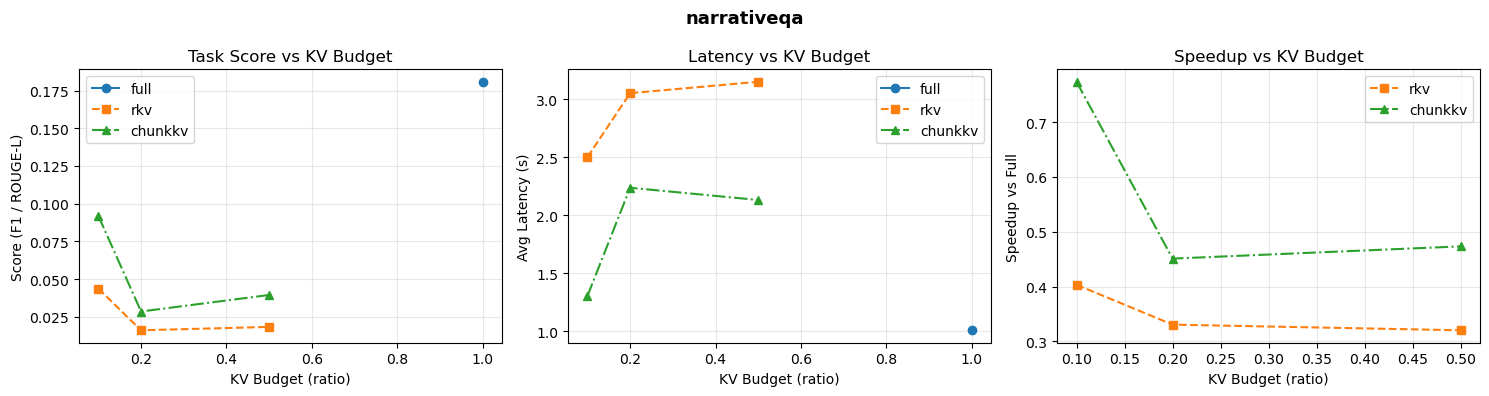

Saved plot: kv_longbench_outputs/narrativeqa_plot.png

==================== qasper ====================
Loaded qasper: 50 samples

  → method=full  budget=1.0


full@1.0:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.1


rkv@0.1:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.2


...


  → method=chunkkv  budget=0.2


chunkkv@0.2:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=chunkkv  budget=0.5


chunkkv@0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Saved: kv_longbench_outputs/qasper_results.csv

── qasper Summary ──
 method  kv_budget  avg_score  avg_latency   avg_tps  avg_gen_tokens  avg_final_cache  avg_cache_len  speedup
chunkkv        0.1   0.152988     1.426385 21.240086           35.58           374.20     366.637038 0.862400
chunkkv        0.2   0.047602     2.058287 26.904172           57.18           762.12     760.029708 0.597640
chunkkv        0.5   0.065322     1.742073 23.358682           44.54          1906.34    1903.220647 0.706121
   full        1.0   0.293636     1.230114 24.338403           31.98          3851.44    3835.950000 1.000000
    rkv        0.1   0.039416     2.834561 20.610320           60.40           381.60     381.600000 0.433970
    rkv        0.2   0.051468     2.943105 21.123075           62.80           763.44     763.440000 0.417965
    rkv        0.5   0.033816     3.111364 20.621365           64.00          1910.14    1910.140000 0.395362


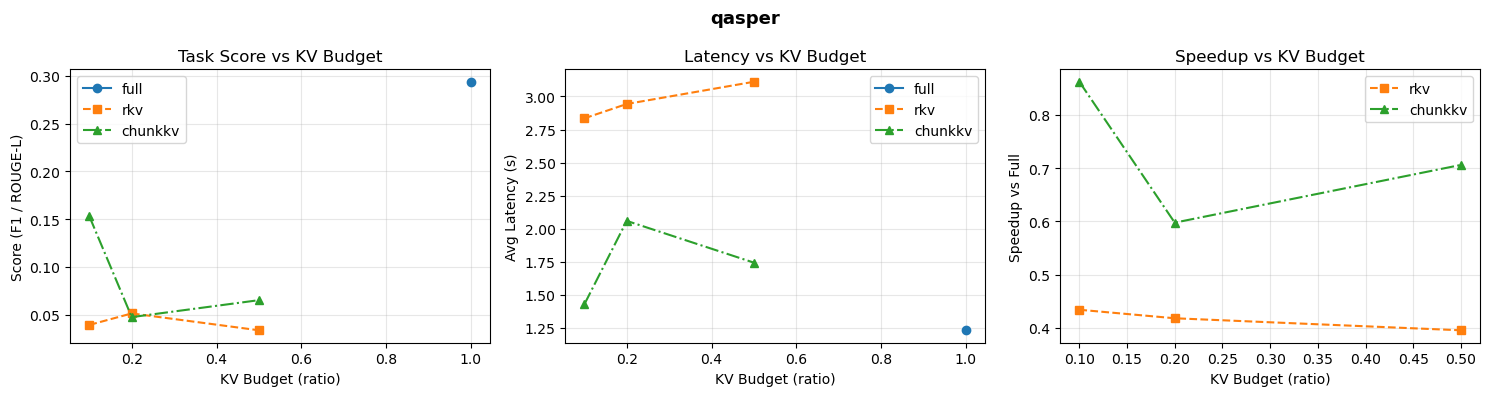

Saved plot: kv_longbench_outputs/qasper_plot.png

==================== multifieldqa_en ====================
Loaded multifieldqa_en: 50 samples

  → method=full  budget=1.0


full@1.0:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.1


rkv@0.1:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.2


...


  → method=chunkkv  budget=0.2


chunkkv@0.2:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=chunkkv  budget=0.5


chunkkv@0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Saved: kv_longbench_outputs/multifieldqa_en_results.csv

── multifieldqa_en Summary ──
 method  kv_budget  avg_score  avg_latency   avg_tps  avg_gen_tokens  avg_final_cache  avg_cache_len  speedup
chunkkv        0.1   0.133299     1.515190 22.533591           38.44           374.12     368.643013 0.757108
chunkkv        0.2   0.047472     1.990960 25.768364           54.14           760.02     758.811251 0.576185
chunkkv        0.5   0.079878     1.902751 24.011085           49.86          1899.58    1897.729663 0.602897
   full        1.0   0.466925     1.147162 24.321834           29.38          3832.22    3818.030000 1.000000
    rkv        0.1   0.081307     2.671385 20.593462           57.28           379.98     379.980000 0.429426
    rkv        0.2   0.053435     2.876441 21.479499           61.94           760.10     760.100000 0.398813
    rkv        0.5   0.062330     3.069696 20.556366           62.96          1901.84    1901.840000 0.373705


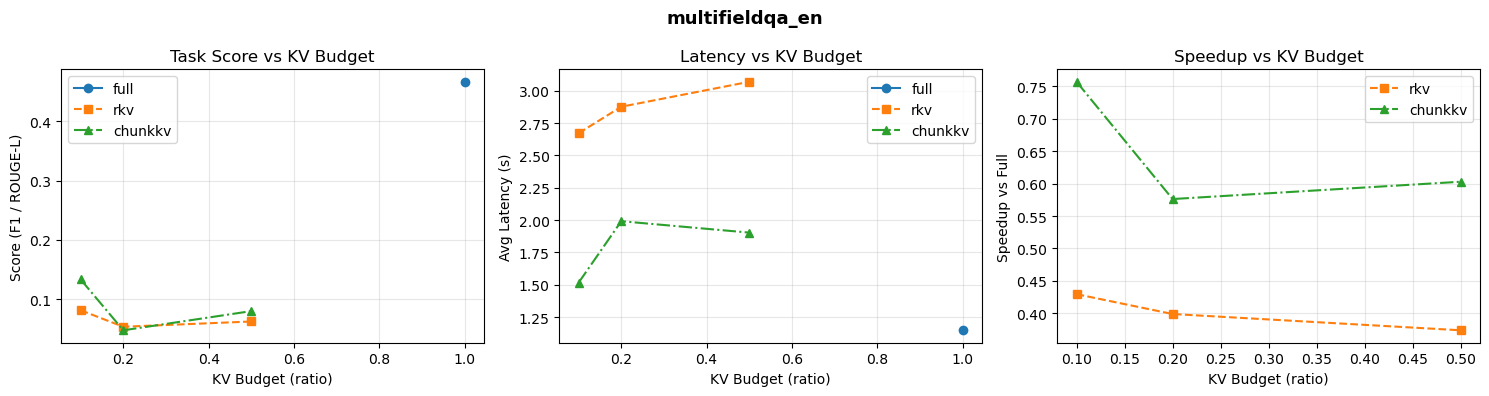

Saved plot: kv_longbench_outputs/multifieldqa_en_plot.png

==================== gov_report ====================
Loaded gov_report: 50 samples

  → method=full  budget=1.0


full@1.0:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.1


rkv@0.1:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.2


...


  → method=chunkkv  budget=0.2


chunkkv@0.2:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=chunkkv  budget=0.5


chunkkv@0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Saved: kv_longbench_outputs/gov_report_results.csv

── gov_report Summary ──
 method  kv_budget  avg_score  avg_latency   avg_tps  avg_gen_tokens  avg_final_cache  avg_cache_len  speedup
chunkkv        0.1   0.078775     2.099739 27.941520           59.32           398.68     391.852110 0.959585
chunkkv        0.2   0.024264     2.044410 25.366808           54.90           797.54     796.773160 0.985555
chunkkv        0.5   0.054603     2.183329 26.183452           58.78          1995.68    1993.902325 0.922847
   full        1.0   0.157919     2.014879 31.795054           64.00          4054.76    4023.260000 1.000000
    rkv        0.1   0.028565     2.995835 21.376799           64.00           398.76     398.760000 0.672560
    rkv        0.2   0.033599     2.869719 20.204052           60.30           797.62     797.620000 0.702117
    rkv        0.5   0.031669     3.168766 20.222786           64.00          1995.82    1995.820000 0.635856


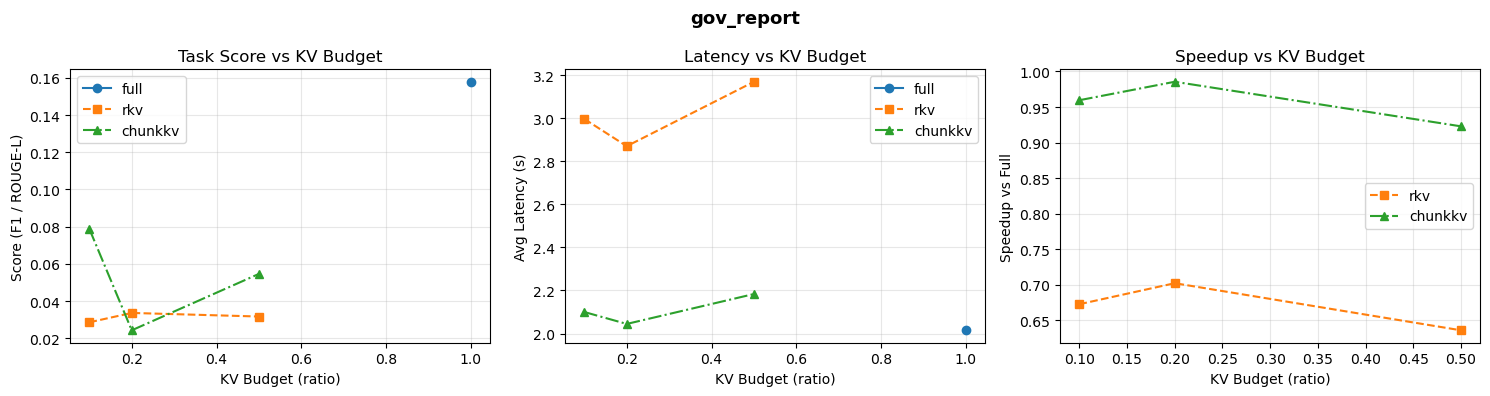

Saved plot: kv_longbench_outputs/gov_report_plot.png

==================== hotpotqa ====================
Loaded hotpotqa: 50 samples

  → method=full  budget=1.0


full@1.0:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.1


rkv@0.1:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.2


...


  → method=chunkkv  budget=0.2


chunkkv@0.2:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=chunkkv  budget=0.5


chunkkv@0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Saved: kv_longbench_outputs/hotpotqa_results.csv

── hotpotqa Summary ──
 method  kv_budget  avg_score  avg_latency   avg_tps  avg_gen_tokens  avg_final_cache  avg_cache_len  speedup
chunkkv        0.1   0.058065     1.262059 17.240694           27.04           390.00     384.544626 0.815151
chunkkv        0.2   0.024413     1.913428 23.096049           48.96           804.68     804.399553 0.537657
chunkkv        0.5   0.030814     2.153320 25.225817           56.46          2011.94    2010.687435 0.477759
   full        1.0   0.133457     1.028769 19.623290           22.42          4046.30    4035.590000 1.000000
    rkv        0.1   0.050528     2.551035 18.427683           52.36           402.02     402.020000 0.403275
    rkv        0.2   0.034444     2.924334 20.615804           61.62           804.68     804.680000 0.351796
    rkv        0.5   0.023430     3.098906 19.581233           61.74          2012.12    2012.120000 0.331978


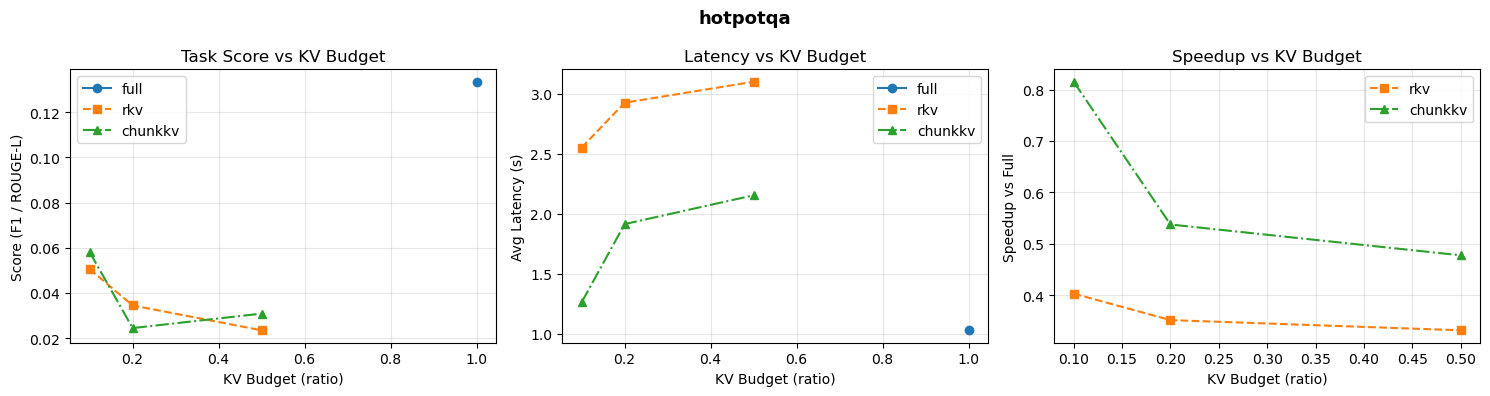

Saved plot: kv_longbench_outputs/hotpotqa_plot.png

==================== 2wikimqa ====================
Loaded 2wikimqa: 50 samples

  → method=full  budget=1.0


full@1.0:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.1


rkv@0.1:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=rkv  budget=0.2


...


  → method=chunkkv  budget=0.2


chunkkv@0.2:   0%|          | 0/50 [00:00<?, ?it/s]


  → method=chunkkv  budget=0.5


chunkkv@0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Saved: kv_longbench_outputs/2wikimqa_results.csv

── 2wikimqa Summary ──
 method  kv_budget  avg_score  avg_latency   avg_tps  avg_gen_tokens  avg_final_cache  avg_cache_len  speedup
chunkkv        0.1   0.101524     1.302764 17.840957           29.26           375.40     371.288972 0.740174
chunkkv        0.2   0.038995     2.092001 25.508679           56.42           772.00     771.888318 0.460933
chunkkv        0.5   0.076746     2.134998 25.803818           57.16          1929.40    1928.016383 0.451650
   full        1.0   0.198995     0.964272 20.103627           21.06          3882.50    3872.470000 1.000000
    rkv        0.1   0.040721     2.571647 18.345231           51.90           386.02     386.020000 0.374963
    rkv        0.2   0.041758     2.941936 20.616264           61.68           772.00     772.000000 0.327768
    rkv        0.5   0.074964     3.085521 19.741461           61.76          1931.06    1931.060000 0.312515


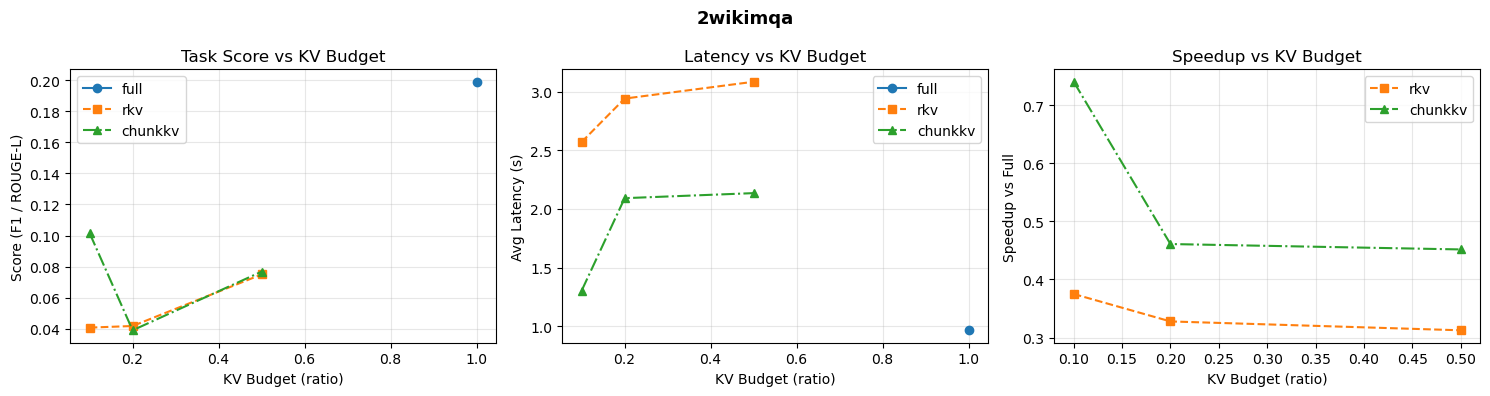

Saved plot: kv_longbench_outputs/2wikimqa_plot.png

Saved combined results → kv_longbench_outputs/all_results.csv

── Grand Summary (avg score by task / method / budget) ──
task             method   kv_budget
2wikimqa         chunkkv  0.1          0.1015
                          0.2          0.0390
                          0.5          0.0767
                 full     1.0          0.1990
                 rkv      0.1          0.0407
                          0.2          0.0418
                          0.5          0.0750
gov_report       chunkkv  0.1          0.0788
                          0.2          0.0243
                          0.5          0.0546
                 full     1.0          0.1579
                 rkv      0.1          0.0286
                          0.2          0.0336
                          0.5          0.0317
hotpotqa         chunkkv  0.1          0.0581
                          0.2          0.0244
                          0.5          0.0308
         

In [19]:
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────
# Method dispatch
# ──────────────────────────────────────────────

METHODS_CONFIG = {
    "full":    [1.0],
    "rkv":     COMPRESSED_RATIOS,
    "chunkkv": COMPRESSED_RATIOS,
}

PLOT_STYLES = {
    "full":    {"marker": "o", "linestyle": "-",  "color": "C0"},
    "rkv":     {"marker": "s", "linestyle": "--", "color": "C1"},
    "chunkkv": {"marker": "^", "linestyle": "-.", "color": "C2"},
}


def run_one_example(task_name: str, example: dict, method_name: str, budget: float) -> dict:
    prompt = build_prompt(example, task_name)
    answers = get_field(example, ["answers", "answer"], [])
    if isinstance(answers, str):
        answers = [answers]

    if method_name == "full":
        result = generate_baseline_stepwise(prompt, max_new_tokens=MAX_NEW_TOKENS)
    elif method_name == "rkv":
        compressor = RKVCompressor(budget_ratio=budget, recent_window=RECENT_WINDOW)
        result = generate_with_compressor(prompt, compressor, max_new_tokens=MAX_NEW_TOKENS)
    else:  # chunkkv
        compressor = ChunkKVCompressor(budget_ratio=budget, recent_window=RECENT_WINDOW)
        result = generate_with_compressor(prompt, compressor, max_new_tokens=MAX_NEW_TOKENS)

    score, metric_name = score_prediction(task_name, result["text"], answers)

    return {
        "task":             task_name,
        "method":           method_name,
        "kv_budget":        budget,
        "metric":           metric_name,
        "score":            score,
        "latency":          result["latency"],
        "tokens_per_sec":   result["tokens_per_sec"],
        "generated_tokens": result["generated_tokens"],
        "final_cache_len":  result["final_cache_len"],
        "avg_cache_len":    result["avg_cache_len"],
        "prediction":       result["text"],
        "answers":          json.dumps(
                                answers if isinstance(answers, list) else [answers],
                                ensure_ascii=False
                            ),
    }


# ──────────────────────────────────────────────
# Main evaluation loop  (follows Qwen guideline: task → method → budget → example)
# ──────────────────────────────────────────────

all_records: List[dict] = []

for task in TASKS:
    print(f"\n{'='*20} {task} {'='*20}")
    lb = load_longbench_subset(task)
    if lb is None:
        continue

    task_records: List[dict] = []

    for method_name, budgets in METHODS_CONFIG.items():
        for budget in budgets:
            print(f"\n  → method={method_name}  budget={budget}")
            for i, example in enumerate(tqdm(lb, desc=f"{method_name}@{budget}")):
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                try:
                    record = run_one_example(task, example, method_name, budget)
                    record["example_id"] = i
                    task_records.append(record)
                except RuntimeError as exc:
                    print(f"  !! SKIPPED task={task} ex={i} method={method_name} budget={budget}: {exc}")
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

    df_task = pd.DataFrame(task_records)
    task_csv = OUTPUT_DIR / f"{task}_results.csv"
    df_task.to_csv(task_csv, index=False)
    print(f"Saved: {task_csv}")

    # ── Per-task summary ──────────────────────────────────────────────────
    agg = (
        df_task
        .groupby(["method", "kv_budget"])
        .agg(
            avg_score         = ("score",            "mean"), 
            avg_latency       = ("latency",          "mean"),
            avg_tps           = ("tokens_per_sec",   "mean"),
            avg_gen_tokens    = ("generated_tokens", "mean"),
            avg_final_cache   = ("final_cache_len",  "mean"),
            avg_cache_len     = ("avg_cache_len",    "mean"),
        )
        .reset_index()
    )

    full_lat = agg.loc[agg["method"] == "full", "avg_latency"].values
    if len(full_lat) and full_lat[0] > 0:
        agg["speedup"] = full_lat[0] / agg["avg_latency"]

    print(f"\n── {task} Summary ──")
    print(agg.to_string(index=False))

    # ── Plots ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(task, fontsize=13, fontweight="bold")

    for method in ["full", "rkv", "chunkkv"]:
        sub = agg[agg["method"] == method].sort_values("kv_budget")
        if sub.empty:
            continue
        kw = PLOT_STYLES[method]
        axes[0].plot(sub["kv_budget"], sub["avg_score"],   label=method, **kw)
        axes[1].plot(sub["kv_budget"], sub["avg_latency"], label=method, **kw)
        if "speedup" in agg.columns and method != "full":
            axes[2].plot(sub["kv_budget"], sub["speedup"], label=method, **kw)

    axes[0].set(title="Task Score vs KV Budget",
                xlabel="KV Budget (ratio)", ylabel="Score (F1 / ROUGE-L)")
    axes[1].set(title="Latency vs KV Budget",
                xlabel="KV Budget (ratio)", ylabel="Avg Latency (s)")
    axes[2].set(title="Speedup vs KV Budget",
                xlabel="KV Budget (ratio)", ylabel="Speedup vs Full")

    for ax in axes:
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plot_path = OUTPUT_DIR / f"{task}_plot.png"
    fig.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {plot_path}")

    all_records.extend(task_records)

    del lb, task_records, df_task, agg
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Combined output ───────────────────────────────────────────────────────
df_all = pd.DataFrame(all_records)
combined_csv = OUTPUT_DIR / "all_results.csv"
df_all.to_csv(combined_csv, index=False)
print(f"\nSaved combined results → {combined_csv}")

print("\n── Grand Summary (avg score by task / method / budget) ──")
print(
    df_all
    .groupby(["task", "method", "kv_budget"])["score"]
    .mean()
    .round(4)
    .to_string()
)



In [26]:
# ──────────────────────────────────────────────
# Re-score saved CSV with the current score_prediction function.
# Run this cell alone after updating the scoring functions —
# no need to re-run inference.
# ──────────────────────────────────────────────

RESCORE_CSV = Path("/home/jovyan/rkvchunkv3.9/kv_longbench_outputs/all_results.csv")

df_rescore = pd.read_csv(RESCORE_CSV)

# Re-score predictions with the current scoring function
new_scores = []
for _, row in df_rescore.iterrows():
    answers = json.loads(row["answers"]) if isinstance(row["answers"], str) else [str(row["answers"])]
    score, metric = score_prediction(row["task"], str(row["prediction"]), answers)
    new_scores.append({"score": score, "metric": metric})

df_rescore[["score", "metric"]] = pd.DataFrame(new_scores, index=df_rescore.index)

# KV cache memory in MB (Qwen2.5-1.5B: 28 layers × 2 KV heads × head_dim 128 × K+V × bfloat16)
_BYTES_PER_TOKEN = 28 * 2 * 128 * 2 * 2
df_rescore["kv_cache_mb"] = (df_rescore["final_cache_len"] * _BYTES_PER_TOKEN / (1024 ** 2)).round(1)

# Save with a distinct name so the original is preserved
rescored_path = RESCORE_CSV.with_name(RESCORE_CSV.stem + "_rescored.csv")
df_rescore.to_csv(rescored_path, index=False)
print(f"Saved rescored results → {rescored_path}")

# ── Per-task summary: score, latency, memory ──────────────────────────────
summary = (
    df_rescore
    .groupby(["task", "method", "kv_budget"])
    .agg(
        score_mean   = ("score",       "mean"),
        latency_mean = ("latency",     "mean"),
        kv_cache_mb  = ("kv_cache_mb", "mean"),
    )
    .round(4)
    .reset_index()
)
print("\n── Score | Latency | KV Cache Memory  (per task / method / budget) ──")
print(summary.to_string(index=False))

# ── Overall averages collapsed across all tasks ───────────────────────────
overall = (
    df_rescore
    .groupby(["method", "kv_budget"])
    .agg(
        score_mean   = ("score",       "mean"),
        latency_mean = ("latency",     "mean"),
        kv_cache_mb  = ("kv_cache_mb", "mean"),
    )
    .round(4)
    .reset_index()
    .sort_values(["method", "kv_budget"])
)
print("\n── Overall Averages (all tasks combined) ──")
print(overall.to_string(index=False))

Saved rescored results → /home/jovyan/rkvchunkv3.9/kv_longbench_outputs/all_results_rescored.csv

── Score | Latency | KV Cache Memory  (per task / method / budget) ──
           task  method  kv_budget  score_mean  latency_mean  kv_cache_mb
       2wikimqa chunkkv        0.1      0.1015        1.3028       10.258
       2wikimqa chunkkv        0.2      0.0390        2.0920       21.138
       2wikimqa chunkkv        0.5      0.0767        2.1350       52.760
       2wikimqa    full        1.0      0.1990        0.9643      106.170
       2wikimqa     rkv        0.1      0.0407        2.5716       10.530
       2wikimqa     rkv        0.2      0.0418        2.9419       21.138
       2wikimqa     rkv        0.5      0.0750        3.0855       52.806
     gov_report chunkkv        0.1      0.0788        2.0997       10.876
     gov_report chunkkv        0.2      0.0243        2.0444       21.846
     gov_report chunkkv        0.5      0.0546        2.1833       54.568
     gov_report   

In [23]:
df_check = pd.read_csv("/home/jovyan/rkvchunkv3.9/kv_longbench_outputs/all_results.csv")

print(df_check[df_check["task"] == "narrativeqa"][
    ["method", "kv_budget", "final_cache_len", "avg_cache_len"]
].head(14).to_string())

   method  kv_budget  final_cache_len  avg_cache_len
0    full        1.0             4093         4083.5
1    full        1.0             4088         4081.0
2    full        1.0             4086         4080.5
3    full        1.0             4099         4086.5
4    full        1.0             4107         4091.0
5    full        1.0             4101         4088.0
6    full        1.0             4093         4083.5
7    full        1.0             4088         4080.5
8    full        1.0             4081         4077.5
9    full        1.0             4086         4080.5
10   full        1.0             4138         4106.5
11   full        1.0             4090         4082.5
12   full        1.0             4077         4076.0
13   full        1.0             4092         4083.5


In [24]:
print(df_check[df_check["task"] == "narrativeqa"][["prediction", "answers"]].head(5).to_string())

                                                                                                                                      prediction                                                          answers
0                                                                       Saltram is living with the Mulvilles, who are in a state of destitution.                  ["He is a guest in the home of the Mulvilles."]
1                                                                              Mary's husband, Henry, does not return her feelings of affection.          ["Because she is in unrequited love with someone else"]
2                                                                                            The witch lives on Atlas' mountain within a cavern.                                          ["The Atlas Mountains"]
3                                  Crito's visit was to bring Socrates a message of a painful nature, and to persuade him to escape from prison.  ["To smuggle S

In [ ]:
df_check = pd.read_csv("/home/jovyan/rkvchunkv3.9/kv_longbench_outputs-Copy1/all_results.csv")

# What columns exist?
print("Columns:", df_check.columns.tolist())
print("Shape:", df_check.shape)
print()

# Are predictions actually varying?
print("Sample predictions (narrativeqa, first 5 rows):")
sample = df_check[df_check["task"] == "narrativeqa"][["method", "kv_budget", "prediction"]].head(10)
print(sample.to_string())

## 4. Analysis: Theoretical and Empirical

### Why each method works or doesn’t

- **R-KV:** Prioritizes important and non-redundant tokens. In long documents, many tokens repeat or add little (e.g., filler). By scoring with embedding norm and local dissimilarity, we keep diverse, salient tokens. **When it works:** Document QA where key facts are spread out and redundancy is high. **When it fails:** When critical details are in “redundant-looking” or low-norm segments, or when order matters strongly (we reorder by selection).

- **ChunkKV:** Keeps whole chunks, so local coherence and sentence structure are preserved. Chunk-level scoring (e.g., mean importance) favors chunks that contain central information. **When it works:** Tasks where context is naturally chunked (paragraphs, sections) and answers depend on full sentences. **When it fails:** When the answer depends on a single token or phrase inside an otherwise low-scoring chunk that gets dropped.

### Efficiency–accuracy trade-off

- **Lower cache ratio** → fewer tokens in context → **faster** prefill and decode (clear **speedup**), but **accuracy** can drop if we remove essential content.
- **R-KV** typically keeps more “informative” tokens for the same budget, so at 10–20% cache you may see better accuracy than uniform or random eviction, but still below full context.
- **ChunkKV** trades some flexibility (must keep or drop whole chunks) for coherence; at the same cache ratio it can **outperform** token-level eviction on tasks that need full sentences.

### Interpretation of results

- Compare **accuracy at 10%, 20%, 50%** for R-KV and ChunkKV to the **full** baseline: how much do we lose?
- Compare **speedup** at each ratio: shorter context should give **speedup > 1**; confirm that R-KV and ChunkKV both reduce time vs. full.
- If ChunkKV has higher accuracy at the same ratio on LongBench, it supports that **semantic chunks** help on these QA tasks; if R-KV is better, **redundancy-aware** token selection is more helpful for this benchmark.